In [1]:
import ncu_report
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np
from pathlib import Path

# Data and Output

In [4]:
def displayImage(image, dtype="float32", fig=None, ax=None):
    '''
    Little helper to display bin files.
    
    dtype could be "float32", "complex64", "uint8"
    '''
    arr = np.fromfile(image, dtype=dtype)
    arr = arr.reshape(-1, np.sqrt(len(arr)).astype(int)).real
    if not fig: fig, ax = plt.subplots(figsize=(5,5), layout="constrained")
    ax.imshow(arr, cmap='magma')
    ax.tick_params(labelsize=12)
    return arr

## Space Domain

The first column of the following figures are the original data, the second column the blurred outcome.

The first row is the $512\times512$ grid, the second a random $2048\times2048$ internet kitten.

The grid was produced with $f_x=0.15$ and $f_y=0.4$.

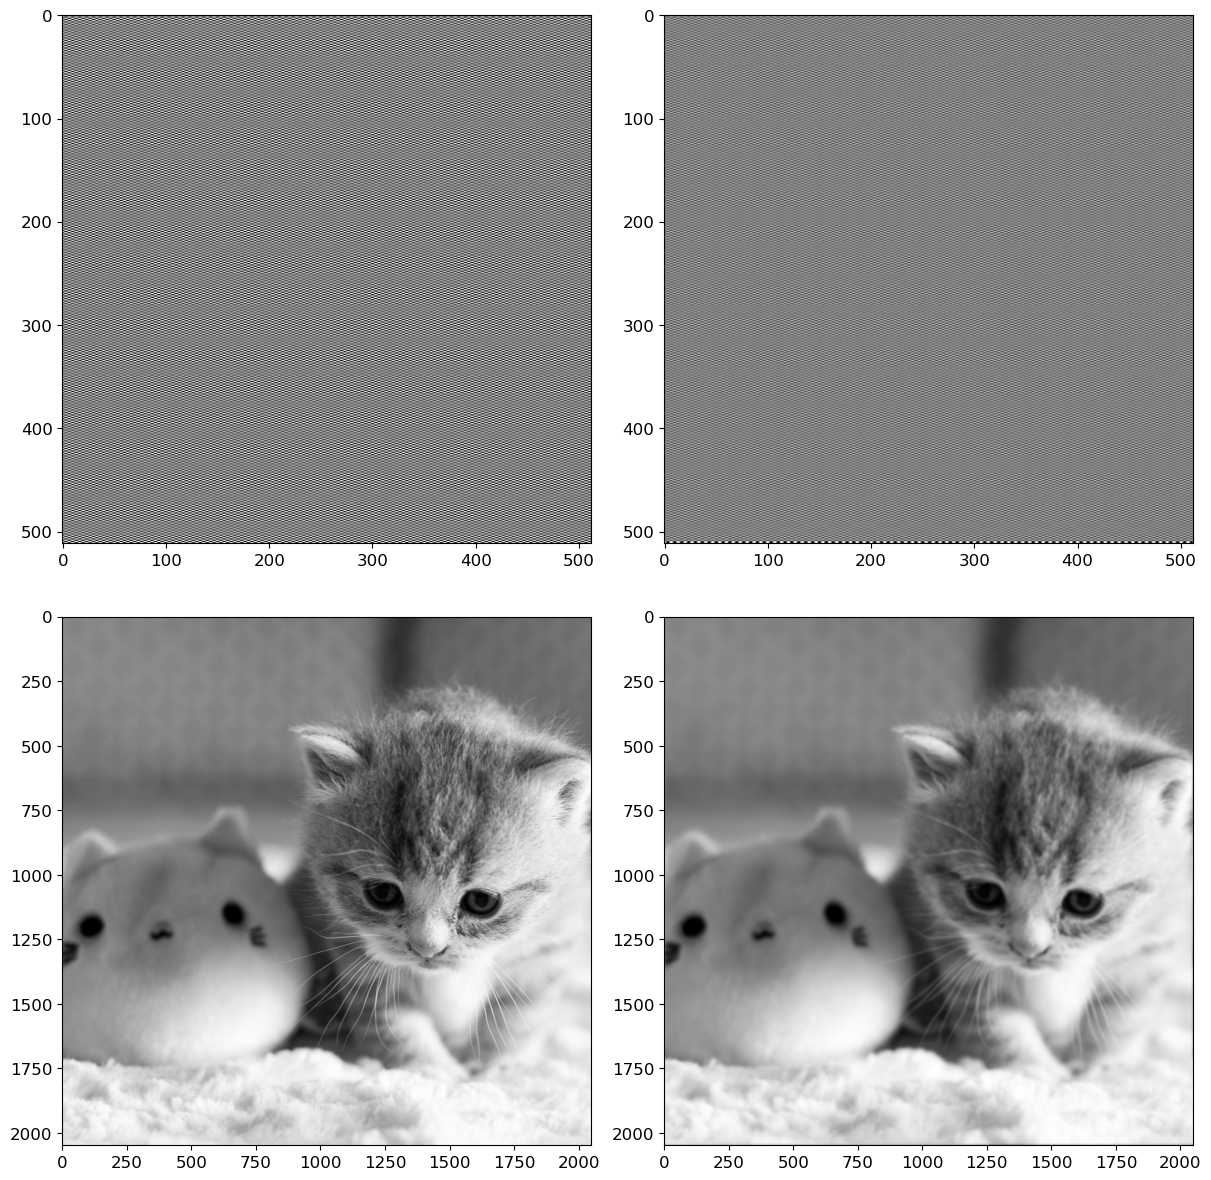

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12,12), layout="constrained")

imgs = ["512.bin", "blurredCos.bin", "cats/cut4K2048.bin", "blurredCat.bin"]

for ax, img in zip(axes.flatten(), imgs): arr = displayImage("data/" + img, dtype="complex64", fig=fig, ax=ax)

## Frequency Domain

The following spectra are centered and put in log-scale for better visualization.

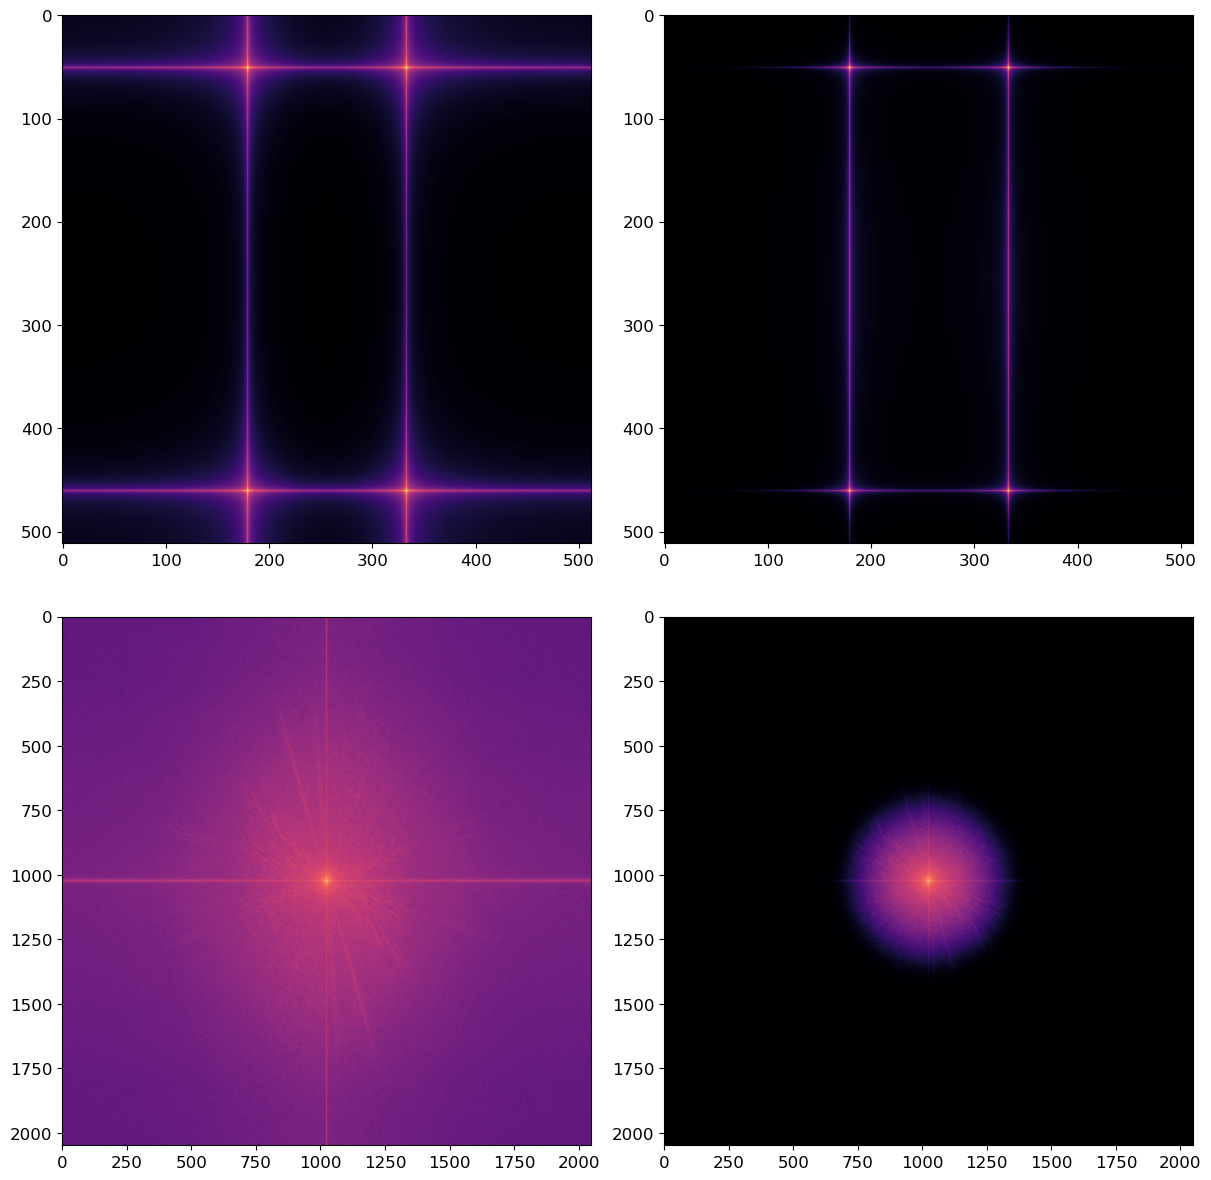

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12,12), layout="constrained")

imgs = ["furiousCos.bin", "furiousCosGauss.bin", "furiousCat.bin", "furiousCatGauss.bin"]

for ax, img in zip(axes.flatten(), imgs): arr = displayImage("data/" + img, dtype="float32", fig=fig, ax=ax)

## Not centered grid spectrum

The following is the spectrum (not centered) of the $512\times512$ grid data. The ticks on the figure show the $N\cdot f_i$ and $N\left(1 - f_i\right)$ (rounded) frequencies where the peak are expected to be. Since these values are not integers, spectral leakage is present.

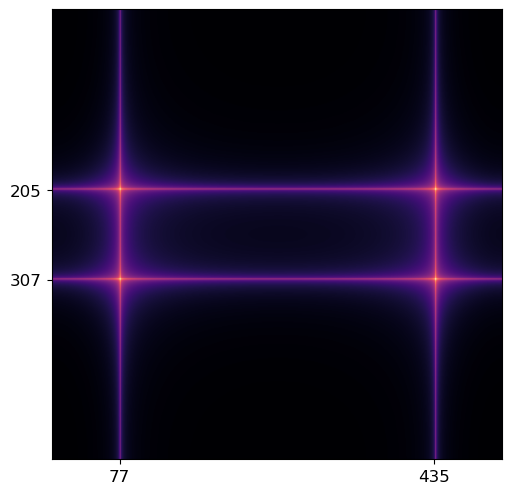

In [6]:
arr = np.fromfile("data/uncentered.bin", dtype="float32")
arr = arr.reshape(-1, np.sqrt(len(arr)).astype(int)).real
fig, ax = plt.subplots(figsize=(5,5), layout="constrained")
ax.imshow(arr, cmap='magma', interpolation=None)
ax.tick_params(labelsize=12)
# Theoretical peaks (since N*f_i is not integer, there will be spectral leakage)
xT = round(512 * .15)
yT = round(512 * .4)
ax.set_xticks([xT, 512 - xT])
ax.set_yticks([yT, 512 - yT])
plt.show()

# Benchmarks

## OMP

### Single Operation

Single operation times taken with the `<chrono>` cpp library. Each operation is tested with static and dynamic thread scheduling.

Each operation is timed $50$ times. Times are in $\left[s\right]$.

In [56]:
wdir = Path("logs/singleImage/OMP/")

In [57]:
statFunc = pd.read_csv(wdir/"centerRevFftTGaussIfftStatic.csv", sep=' ', names=["threads", "N", "Center", "Bit-rev", "FFT", "T", "Gauss", "IFFT"], header=None)
dynFunc = pd.read_csv(wdir/"centerRevFftTGaussIfftDynamic.csv", sep=' ', names=["threads", "N", "Center", "Bit-rev", "FFT", "T", "Gauss", "IFFT"], header=None)
statFunc

,threads,N,Center,Bit-rev,FFT,T,Gauss,IFFT
0,2,512,0.000165,0.000002,0.002243,0.000309,0.000768,0.002225
1,2,512,0.000131,0.000002,0.002723,0.000328,0.000792,0.002425
2,2,512,0.000152,0.000003,0.002233,0.000385,0.000748,0.002139
3,2,512,0.000142,0.000003,0.002216,0.000359,0.000747,0.002353
4,2,512,0.000162,0.000002,0.002228,0.000374,0.000753,0.002315
...,...,...,...,...,...,...,...,...
2095,8,16384,0.152992,0.000049,1.843980,0.366678,0.387886,2.138950
2096,8,16384,0.153165,0.000042,1.854030,0.367238,0.397550,2.142130
2097,8,16384,0.153001,0.000042,1.842200,0.367434,0.386871,2.138040
2098,8,16384,0.153207,0.000048,1.844380,0.367856,0.394758,2.138740


In [11]:
cmap = ['k', "#E69F00", "#D55E00", "#56B4E9", "#0072B2", "#009E73", ]

firstC = cmap[:3]
secondC = cmap[3:]

firstKwargs = {"y":"mean", "yerr":"std", "capsize":2, "fontsize":12}
secondKwargs = {"y":"mean", "yerr":"std", "ls":"--", "capsize":2, "alpha":.5, "fontsize":12, "legend":False}

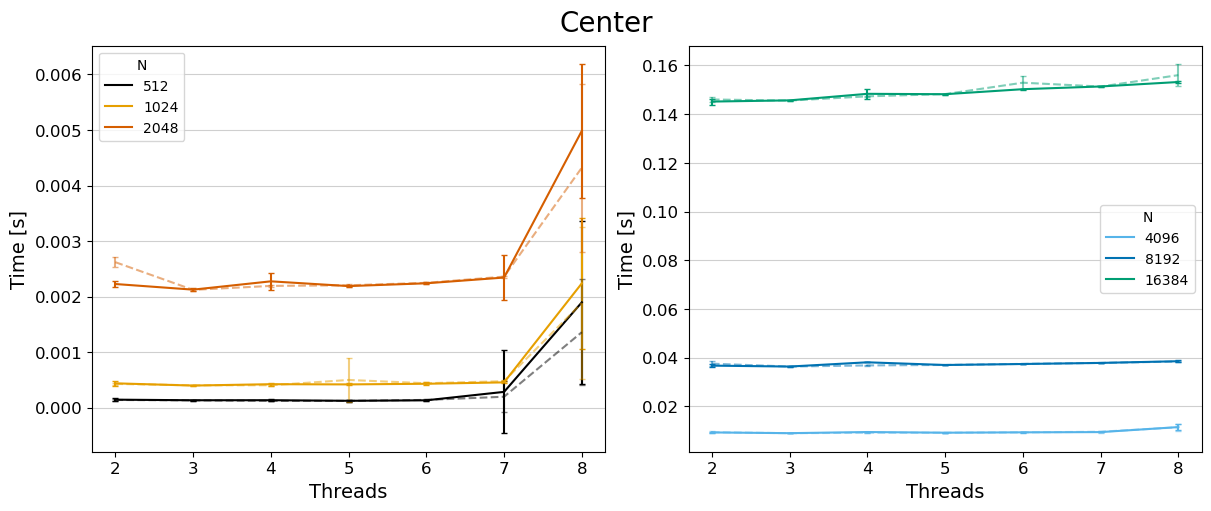

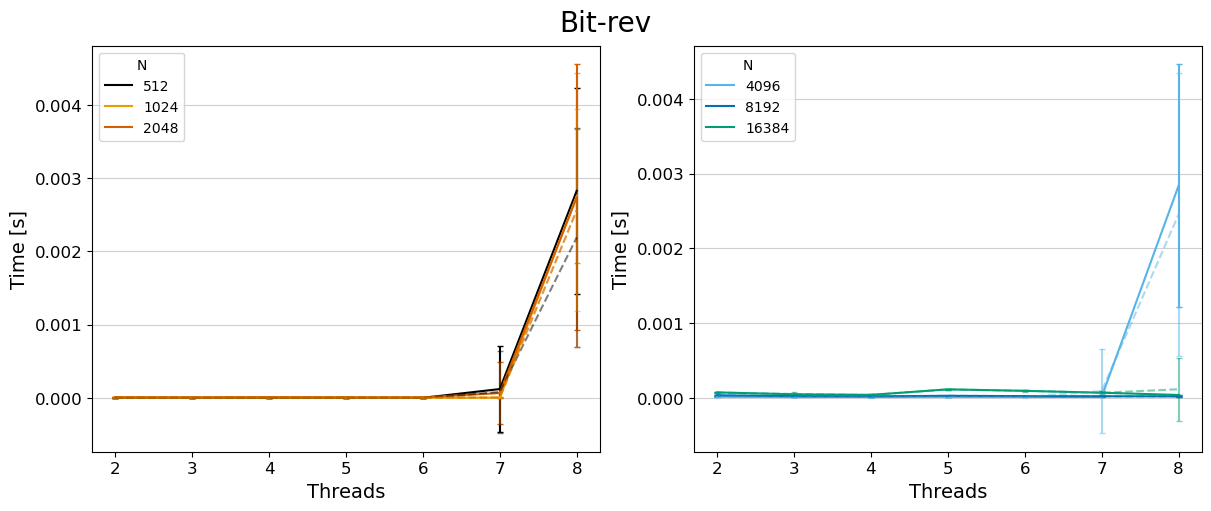

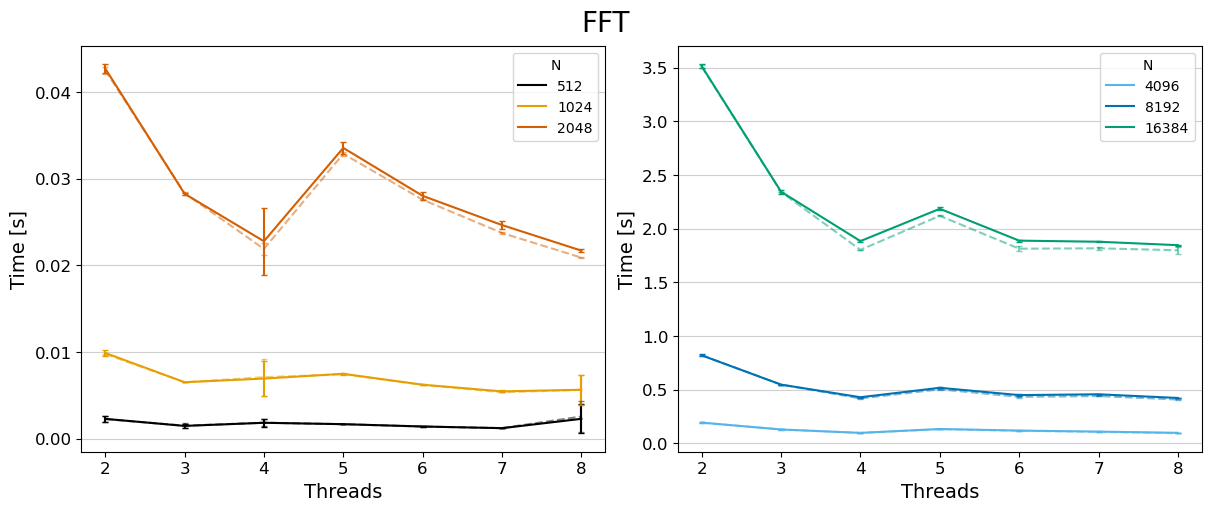

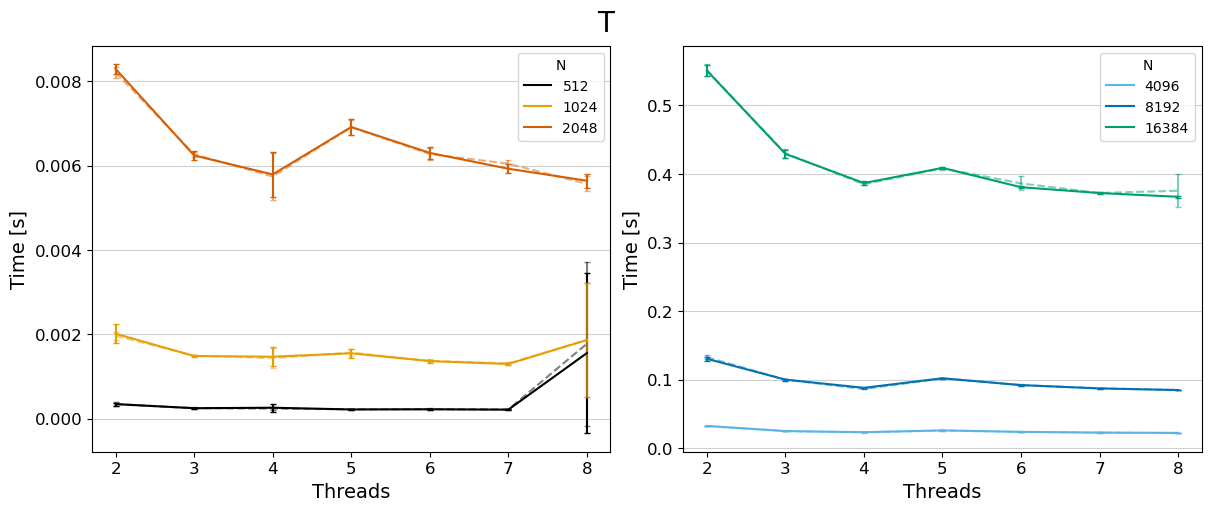

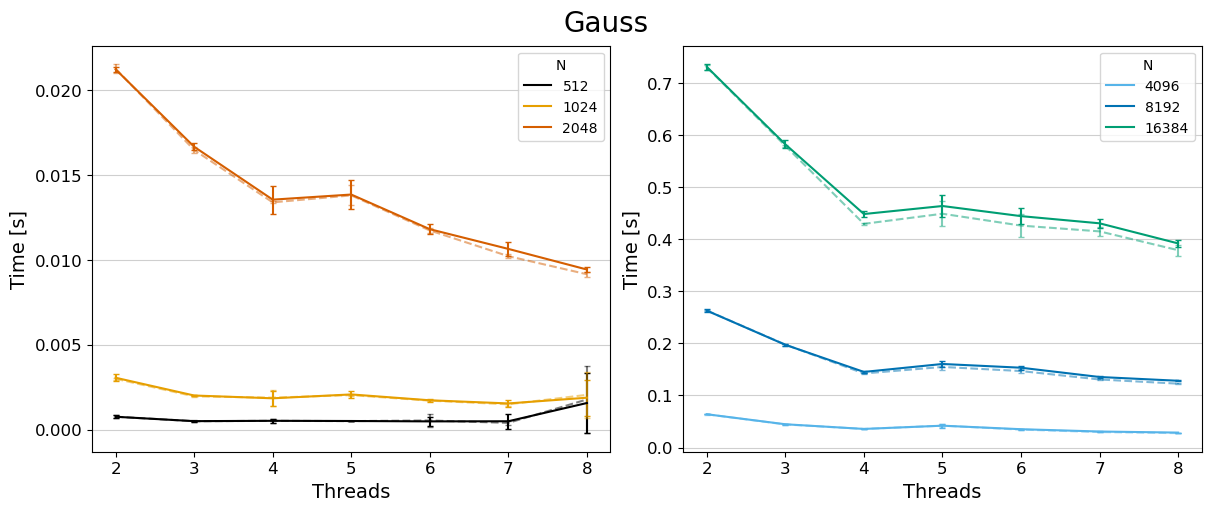

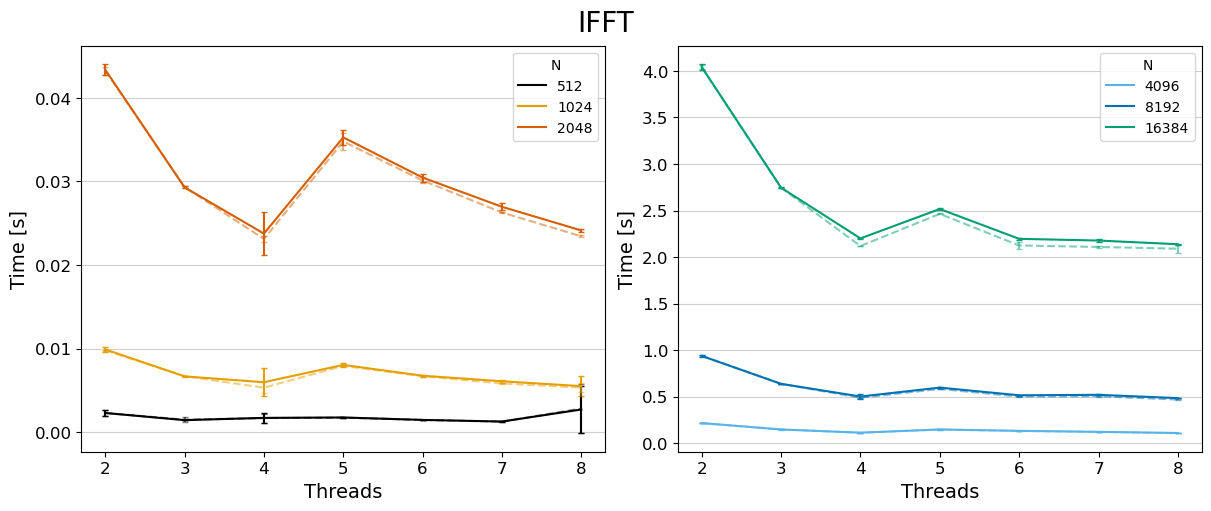

In [12]:
for name in statFunc.columns[2:]:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
    fig.suptitle(name, fontsize=20)
    
    statFuncMeanStd = statFunc.groupby(["threads", "N"]).agg(["mean", "std"])[name].unstack()
    dynFuncMeanStd = dynFunc.groupby(["threads", "N"]).agg(["mean", "std"])[name].unstack()
    
    ax[0].set_prop_cycle(cycler(color=firstC))
    statFuncMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**firstKwargs, ax=ax[0])
    dynFuncMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**secondKwargs, ax=ax[0])
    
    ax[1].set_prop_cycle(cycler(color=secondC))
    statFuncMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**firstKwargs, ax=ax[1])
    dynFuncMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**secondKwargs, ax=ax[1])

    for Ax in ax:
        Ax.grid(axis='y', alpha=.6)
        Ax.set_xlabel("Threads", fontsize=14)
        Ax.set_ylabel("Time [s]", fontsize=14)


plt.show()

Since the workload is quite evenly distributed, there is almost no difference between dynamic and static scheduling.

Notice the bump at $5$ threads, possibly due to Intel Hyper-Threading CPU architecture where $2$ logical cores are assigned to a single physical core.

### Execution Time

Execution time of the executable taken with the `time` shell command.

In [14]:
staticData = pd.read_csv(wdir/"staticTimes.csv", sep=' ', names=["threads", "N", "real", "user", "sys"], header=None)
dynamicData = pd.read_csv(wdir/"dynamicTimes.csv", sep=' ', names=["threads", "N", "real", "user", "sys"], header=None)
staticData

,threads,N,real,user,sys
0,2,512,0.014,0.023,0.001
1,2,512,0.015,0.023,0.003
2,2,512,0.013,0.022,0.002
3,2,512,0.014,0.023,0.001
4,2,512,0.014,0.024,0.000
...,...,...,...,...,...
2095,8,16384,10.963,79.128,0.434
2096,8,16384,10.946,79.567,0.437
2097,8,16384,10.931,79.041,0.443
2098,8,16384,10.973,79.210,0.405


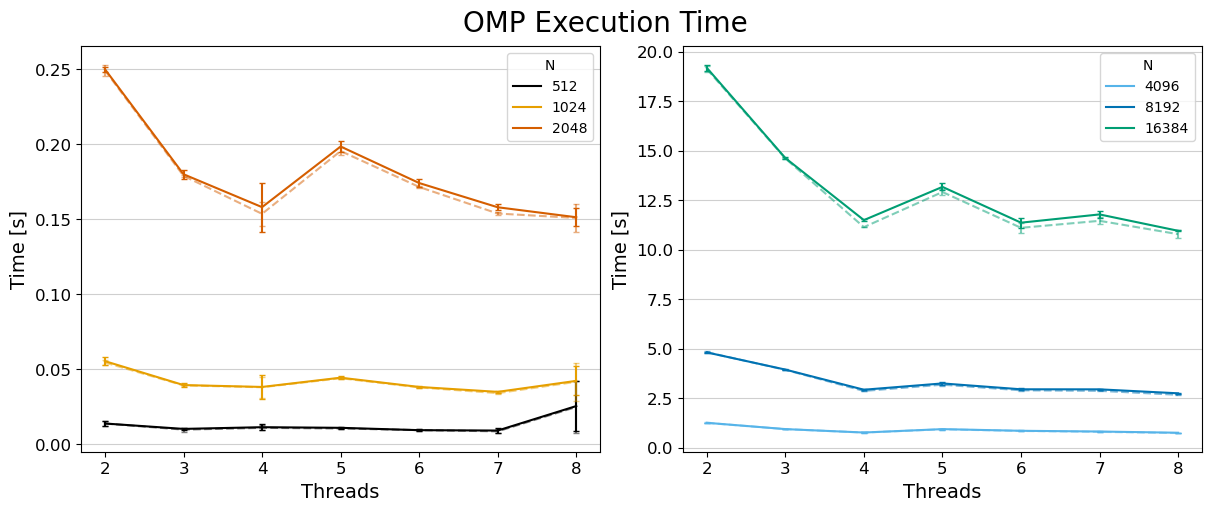

In [15]:
staticMeanStd = staticData.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack()
dynamicMeanStd = dynamicData.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack()

fig, ax = plt.subplots(1,2,figsize=(12,5), layout="constrained")
fig.suptitle("OMP Execution Time", fontsize=20)

ax[0].set_prop_cycle(cycler(color=firstC))
staticMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**firstKwargs, ax=ax[0])
dynamicMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**secondKwargs, ax=ax[0])

ax[1].set_prop_cycle(cycler(color=secondC))
staticMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**firstKwargs, ax=ax[1])
dynamicMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**secondKwargs, ax=ax[1])

for Ax in ax:
    Ax.grid(axis='y', alpha=.6)
    Ax.set_xlabel("Threads", fontsize=14)
    Ax.set_ylabel("Time [s]", fontsize=14)

# plt.savefig("OMPExec.pdf")
plt.show()

Comparison with serial computation.

In [24]:
serialData = pd.read_csv("logs/singleImage/1/times.csv", sep=' ', names=["N", "real", "user", "sys"], header=None).groupby("N").agg(["mean", "std"])["real"]
serialData

,mean,std
N,,
512,0.02802,0.000317
1024,0.11452,0.001176
2048,0.52739,0.002386
4096,2.65138,0.023373
8192,10.18757,0.032612
16384,40.95539,0.073939


OMP speedup:

In [33]:
print("4 Threads (dynamic)")
display(serialData["mean"] / dynamicMeanStd["mean"].loc[4])
print("\n8 Threads (dynamic)")
serialData["mean"] / dynamicMeanStd["mean"].loc[8]

4 Threads (dynamic)


N
512      2.628518
1024     3.034446
2048     3.438005
4096     3.485173
8192     3.558678
16384    3.677377
dtype: float64


8 Threads (dynamic)


N
512      1.139024
1024     2.768859
2048     3.500531
4096     3.618940
8192     3.819804
16384    3.798715
dtype: float64

Using $8$ threads is detrimental wrt $4$ threads for small images. For larger images the difference is possibly still too small to justify an increase in power consumption and heat dissipation (benchmark in this regard should be carried out).

## CUDA & cuFFT

### Kernel times with NCU

Notice that these times are in $\left[ms\right]$.

In [38]:
## To get the total kernel time uncomment the commented lines. These changes the shared memory version of the data reordering kernel with the standard implementation, and viceversa for the transposition kernel.
# times = {}
for N in [2**i for i in range(9, 15)]:
    # times[N] = []
    context = ncu_report.load_report(f"logs/singleImage/cuda/{N}.ncu-rep")
    ncuRange = context[0]
    
    actDict = {}
    for action in ncuRange:
        name = action.name()
        # if (N <= 1024 and name == "revBitShOrdKer") or name == "transposeKer": continue  # calc total time
        time = action.metric_by_name('gpu__time_duration.avg').value() * 1e-6
        # if (N <= 1024 and name == "revBitOrdKer") or name == "sharedTransposeKer": time *= 2  # calc total time
        if actDict.get(name): actDict[name].append(time)
        else: actDict[name] = [time]
        # times[N].append(time)
    print(N)
    for key, item in actDict.items(): print(f"{key} -- # kernels: {len(item)} -- gpu time: {np.mean(item)} +- {np.std(item)} ms")
    print()
    # print("Total Time:", sum(times[N]), "ms\n")
# for key, value in times.items(): times[key] = sum(value)

512
centerKer -- # kernels: 2 -- gpu time: 0.015248 +- 0.0019679999999999993 ms
revBitShOrdKer -- # kernels: 2 -- gpu time: 0.026912 +- 9.599999999999886e-05 ms
coolSubKer -- # kernels: 18 -- gpu time: 0.014839111111111112 +- 0.0007515123188824645 ms
transposeKer -- # kernels: 2 -- gpu time: 0.025664 +- 0.00012799999999999964 ms
gaussKer -- # kernels: 1 -- gpu time: 0.01392 +- 0.0 ms
revBitOrdKer -- # kernels: 2 -- gpu time: 0.035295999999999994 +- 0.00012799999999999964 ms
busLoocKer -- # kernels: 18 -- gpu time: 0.014824888888888887 +- 0.0007719753082471029 ms
sharedTransposeKer -- # kernels: 2 -- gpu time: 0.015184 +- 1.600000000000039e-05 ms
mulKer -- # kernels: 1 -- gpu time: 0.014272 +- 0.0 ms

1024
centerKer -- # kernels: 2 -- gpu time: 0.06767999999999999 +- 0.002239999999999999 ms
revBitShOrdKer -- # kernels: 2 -- gpu time: 0.1132 +- 1.6000000000002124e-05 ms
coolSubKer -- # kernels: 20 -- gpu time: 0.06760479999999999 +- 0.0006842521172784197 ms
transposeKer -- # kernels: 2 -

Total Kernel Times (blazingly faster than CPU times).

In [35]:
times

{512: 0.7945599999999999,
 1024: 3.755296,
 2048: 16.620448,
 4096: 71.32467199999999,
 8192: 302.393312,
 16384: 1281.19984}

### Execution times

In $\left[s\right]$.

In [39]:
wdir = Path("logs/singleImage/cuda/")

In [40]:
cuData = pd.read_csv(wdir/"times.csv", sep=' ', names=["N", "real", "user", "sys"], header=None)
cuMeanStd = cuData.groupby("N").agg(["mean", "std"])["real"].unstack()
cuMeanStd

      N    
mean  512      0.186260
      1024     0.193840
      2048     0.213230
      4096     0.302630
      8192     0.676520
      16384    2.212660
std   512      0.026865
      1024     0.006846
      2048     0.006796
      4096     0.004629
      8192     0.004164
      16384    0.004870
dtype: float64

cufft

In [41]:
cufftData = pd.read_csv("logs/singleImage/cufft/times.csv", sep=' ', names=["N", "real", "user", "sys"], header=None)
cufftMeanStd = cufftData.groupby("N").agg(["mean", "std"])["real"].unstack()
cufftMeanStd

      N    
mean  512      0.188270
      1024     0.189610
      2048     0.200580
      4096     0.249090
      8192     0.427710
      16384    1.135650
std   512      0.023099
      1024     0.005559
      2048     0.005257
      4096     0.006265
      8192     0.004434
      16384    0.003875
dtype: float64

speedup

In [43]:
cuMeanStd["mean"] / cufftMeanStd["mean"]

N
512      0.989324
1024     1.022309
2048     1.063067
4096     1.214942
8192     1.581726
16384    1.948364
dtype: float64

cuFFT is up to $2$ times faster than my implementation. Not being a software engineer, I see this as an absolute win.

## CPU vs GPU

Speedup

In [45]:
dynamicMeanStd["mean"].loc[4] / cufftMeanStd["mean"]

N
512      0.056621
1024     0.199040
2048     0.764782
4096     3.054157
8192     6.693180
16384    9.806824
dtype: float64

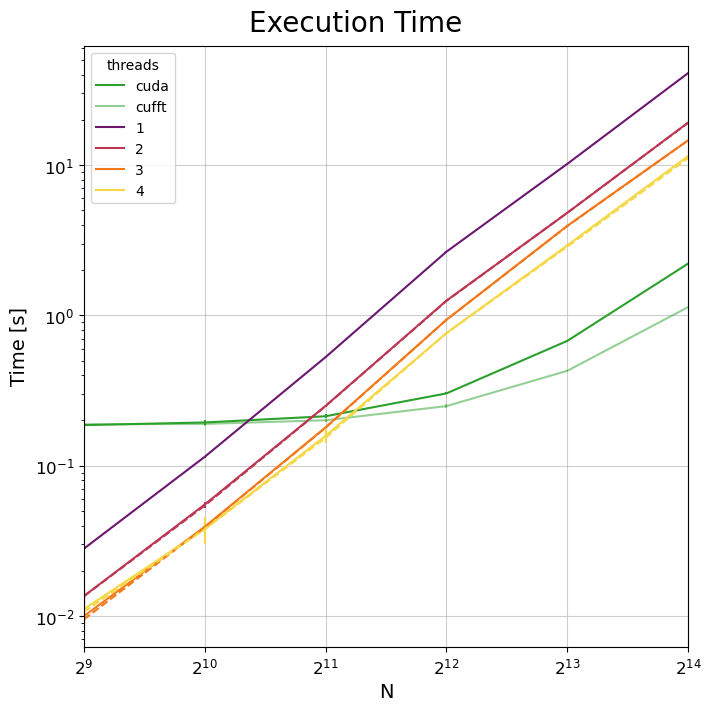

In [44]:
wdir = Path("logs/singleImage/")
pdNames = ["N", "real", "user", "sys"]
colors = plt.get_cmap("inferno")(np.linspace(0.3, 0.9, 4))

fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
fig.suptitle("Execution Time", fontsize=20)
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.set_xlim(512, 16384)

cmap = {
        "1":{"color":colors[0]},
        "cuda":{"color":"tab:green"},
        "cufft":{"color":"tab:green", "alpha":0.5},
        "threads":{"color":colors[1:]}
       }

for file in wdir.glob("**/times.csv"):
    data = pd.read_csv(file, sep=' ', names=pdNames, header=None)
    data.groupby("N").agg(["mean", "std"])["real"].plot(y="mean", yerr="std", xticks=data["N"].unique(), **cmap[file.parent.name], label=file.parent.name, fontsize=12, ax=ax)

for file, kwarg in {"OMP/staticTimes.csv": {"ls": "-"}, "OMP/dynamicTimes.csv": {"ls": "--", "legend": False}}.items():
    data = pd.read_csv(wdir/file, sep=' ', names=["threads"] + pdNames, header=None)
    data = data[data["threads"]<=4]
    data.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack(level=0).plot(y="mean", yerr="std", **cmap["threads"], **kwarg, ax=ax)
    
ax.grid(alpha=.6)
ax.set_xlabel("N", fontsize=14)
ax.set_ylabel("Time [s]", fontsize=14)

# plt.savefig("exec.pdf")
plt.show()

These are terrifying results (particularly because I started working with $N=512$ and $N=1024$ only) as the CPU-GPU delay would not justify the usage of the GPU for smaller images.

Hence I scaled both in dimension (up to $N=16384$) and in number of processed images (see later).

Since the GPU scaling seemed also a bit off I decided to calculate the delay time.

## "Ghost Time"

I add to the kernels' duration the following times:
1. Loading the data.
2. Allocating memory in the GPU global memory.
3. Copying the memory to/from the GPU.

Still, the delay time seems to be somewhat proportional to the image size for unknown reasons.

In [53]:
## ms
loads = pd.read_csv("logs/singleImage/loadingTime.csv", sep=' ', names=["N", "time"], header=None).groupby("N").agg(["mean", "std"]) * 1e3
malloc = pd.read_csv("logs/singleImage/cuda/mallocMemcpyAsync.csv", sep=' ', header=None, names=["N","Malloc", "Memcpy"]).groupby("N").agg(["mean", "std"]) * 2
malloc["totKerTime"] = times
malloc["cudaTotMean"] = cuMeanStd["mean"] * 1e3
malloc["cudaTotStd"] = cuMeanStd["std"] * 1e3
malloc["sum"] = malloc["Malloc", "mean"] + malloc["Memcpy", "mean"] + malloc["totKerTime"] + loads["time", "mean"]
malloc["std"] = malloc["Malloc", "std"] + malloc["Memcpy", "std"] + loads["time", "std"]
malloc["ghostTime"] = malloc["cudaTotMean"] - malloc["sum"]
print("loading time")
display(loads)
display(malloc)

loading time


time          
             mean       std
N                          
512      0.204484  0.080786
1024     0.959502  0.150591
2048     4.218965  0.045328
4096    16.623374  0.141857
8192    62.486282  0.570170
16384  238.819860  1.312306

Malloc                Memcpy             totKerTime cudaTotMean  \
            mean       std        mean       std                            
N                                                                           
512     6.606423  0.398437    0.351294  0.006473     0.794560      186.26   
1024    6.640986  0.395270    1.338210  0.013028     3.755296      193.84   
2048    6.635112  0.384796    5.241482  0.017933    16.620448      213.23   
4096    6.788225  0.395521   20.852532  0.034328    71.324672      302.63   
8192    7.449498  0.372875   83.256328  0.022721   302.393312      676.52   
16384  10.167345  0.486642  333.293660  1.545610  1281.199840     2212.66   

      cudaTotStd          sum       std   ghostTime  
                                                     
N                                                    
512    26.864651     7.956761  0.485696  178.303239  
1024    6.845658    12.693995  0.558889  181.146005  
2048    6.795505    32.716007  0.448057  180.513993  
4096    4.628971   115.588803  0.571706  187.041197  
8192    4.164496   455.585420  0.965766  220.934580  
16384   4.870484  1863.480705  3.344558  349.179295

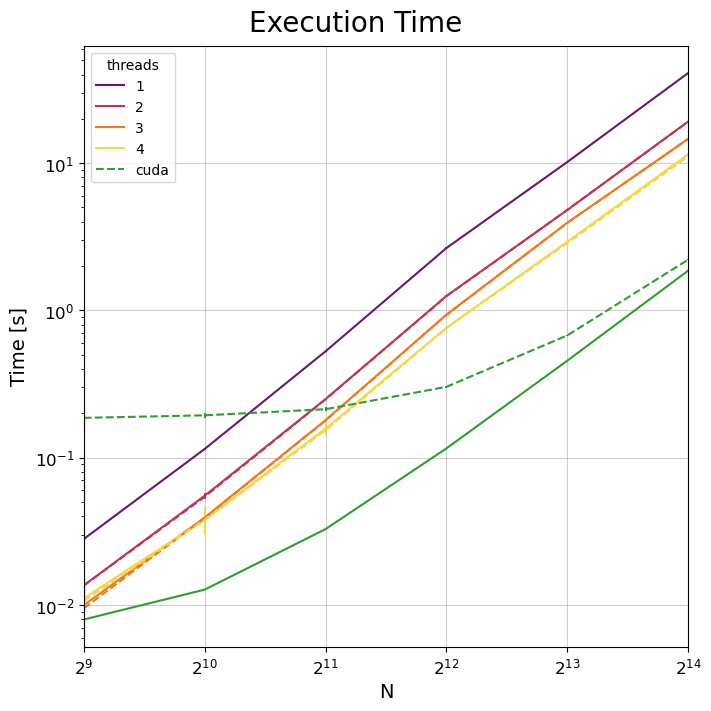

In [54]:
wdir = Path("logs/singleImage/")
pdNames = ["N", "real", "user", "sys"]
colors = plt.get_cmap("inferno")(np.linspace(0.3, 0.9, 4))

fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
fig.suptitle("Execution Time", fontsize=20)
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.set_xlim(512, 16384)

cmap = {
        "1":{"color":colors[0]},
        "cuda":{"color":"tab:green", "alpha":0.5},
        "cufft":{"color":"tab:green"},
        "threads":{"color":colors[1:]}
       }

data = pd.read_csv("logs/singleImage/1/times.csv", sep=' ', names=pdNames, header=None)
data.groupby("N").agg(["mean", "std"])["real"].plot(y="mean", yerr="std", xticks=data["N"].unique(), color=colors[0], label="1", fontsize=12, ax=ax)

for file, kwarg in {"OMP/staticTimes.csv": {"ls": "-"}, "OMP/dynamicTimes.csv": {"ls": "--", "legend": False}}.items():
    data = pd.read_csv(wdir/file, sep=' ', names=["threads"] + pdNames, header=None)
    data = data[data["threads"]<=4]
    data.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack(level=0).plot(y="mean", yerr="std", **cmap["threads"], **kwarg, ax=ax)


pd.read_csv("logs/singleImage/cuda/times.csv", sep=' ', names=pdNames, header=None).groupby("N").agg(["mean", "std"])["real"].plot(y="mean", yerr="std", xticks=data["N"].unique(), color="tab:green", ls="--", label="cuda", fontsize=12, ax=ax)

malloc["threads", "sum"] = malloc["sum"] * 1e-3
malloc["threads", "sum"].plot(color="tab:green", fontsize=12, ax=ax)

ax.grid(alpha=.6)
ax.set_xlabel("N", fontsize=14)
ax.set_ylabel("Time [s]", fontsize=14)

# plt.savefig("corrected.pdf")
plt.show()

Accounting for the delay time, the scaling seems more reasonable.

Still, this does not justify the GPU usage. Which is why I decided to test multiple images processing.

# $100$ $4096\times4096$ Images

Having to process multiple images, I could use multiple cudaStreams to work on multiple images at the same time, maximising the GPU usage (previous cudaKernels had to be cudaProcessed in a serial way).

Already with $2$ cudaStreams I expected to hit the maximum, in fact a third cudaStream does not yield any cudaImprovement.

The "tesla" lines refer to the Tesla T4 CloudVeneto GPUs working in parallel on two different cudaStreams: `1Streams.csv` is the mean time from a single GPU, and `2Streams.csv` from the cudaCollaboration.

In [11]:
wdir = Path("logs/multImages/")
pdNames = ["N", "real", "user", "sys"]

for file in list((wdir.parent/"tesla").glob("*Streams.csv")) + list(wdir.glob("*.csv")):
    data = pd.read_csv(file, sep=' ', names=pdNames, header=None)
    print(file, data["real"].agg(["mean", "std"]).values)

logs/tesla/1Streams.csv [12.41368     0.11940593]
logs/tesla/2Streams.csv [6.75749    0.27346104]
logs/multImages/3Streams.csv [9.77686    0.03354118]
logs/multImages/2Streams.csv [9.75727    0.03576095]
logs/multImages/1Streams.csv [10.71332     0.03444946]
logs/multImages/ser.csv [230.89344      0.33060703]
logs/multImages/omp.csv [69.8962      0.53227022]
logs/multImages/omp4Cores.csv [73.42436364  0.22037063]
logs/multImages/cufft1Stream.csv [4.89473    0.04784083]
logs/multImages/cufft2Streams.csv [3.85517    0.06509854]


Notably the `logs/multImages/1Streams.csv` time is $\sim100$ times the `sum` time of the `malloc` dataframe in the "Ghost Time" section (sum of kernel times, malloc, copying and loading) instead of the single image execution time.

Similar results are found for other image sizes.